
# AdaBoost extension notebook

This notebook runs the separate `adaboost_core.py` implementation, tests the core routines, writes an AdaBoost text report, and displays a compact set of diagnostic plots for the synthetic datasets.


In [1]:

from pathlib import Path
import sys
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

def locate_project_dir():
    candidates = [ROOT, *ROOT.parents]

    for candidate in candidates:
        if (candidate / "adaboost_core.py").exists():
            return candidate

    for candidate in candidates:
        for match in candidate.rglob("adaboost_core.py"):
            parent = match.parent
            if str(parent) not in sys.path:
                sys.path.insert(0, str(parent))
            return parent

    raise FileNotFoundError(
        "Could not locate the project folder. Place adaboost_run.ipynb and adaboost_core.py in the same folder before running."
    )

project_dir = locate_project_dir()
if str(project_dir) not in sys.path:
    sys.path.insert(0, str(project_dir))

print("Working directory:", project_dir)
print("Import root:", sys.path[0])


Working directory: C:\Users\axfjr\Downloads\useful_all_adaboost
Import root: C:\Users\axfjr\Downloads\useful_all_adaboost


In [2]:

import os
os.chdir(project_dir)

import numpy as np
import matplotlib.pyplot as plt

from adaboost_core import (
    default_datasets,
    default_seed,
    normalize_weights,
    entropy,
    effective_sample_size,
    weighted_error,
    weak_learner_edge,
    fit_decision_stump,
    run_adaboost,
    run_default_adaboost_experiments,
    adaboost_report,
    write_adaboost_report,
)



## Configuration

The default experiments use the three built-in synthetic datasets and a default number of boosting rounds. Change `rounds` below if needed.


In [3]:

rounds = 25

results_dir = Path("results_adaboost")
results_dir.mkdir(exist_ok=True)

figures_dir = results_dir / "figures"
figures_dir.mkdir(exist_ok=True)

rounds


25


## Basic function tests

These tests check the main identities and sanity conditions used by the AdaBoost implementation.


In [4]:

tests_passed = []

w = normalize_weights([1, 2, 3])
assert np.isclose(np.sum(w), 1.0)
tests_passed.append("normalize_weights sums to 1")

e_uniform = entropy(np.array([0.25, 0.25, 0.25, 0.25]))
assert e_uniform > 0
tests_passed.append("entropy is positive on a nondegenerate distribution")

ess_uniform = effective_sample_size(np.array([0.25, 0.25, 0.25, 0.25]))
assert np.isclose(ess_uniform, 4.0)
tests_passed.append("effective_sample_size matches the uniform case")

y_true = np.array([1, 1, -1, -1], dtype=float)
y_pred = np.array([1, -1, -1, 1], dtype=float)
w_test = np.array([0.25, 0.25, 0.25, 0.25], dtype=float)
err = weighted_error(w_test, y_true, y_pred)
assert np.isclose(err, 0.5)
tests_passed.append("weighted_error matches the expected value")

edge = weak_learner_edge(0.4)
assert np.isclose(edge, 0.1)
tests_passed.append("weak_learner_edge matches gamma = 1/2 - epsilon")

datasets = default_datasets()
assert set(datasets.keys()) == {"gaussian_easy", "gaussian_overlap", "xor_checkerboard"}
tests_passed.append("default_datasets returned the expected datasets")

display(Markdown("### Core tests passed"))
for item in tests_passed:
    print("-", item)


### Core tests passed

- normalize_weights sums to 1
- entropy is positive on a nondegenerate distribution
- effective_sample_size matches the uniform case
- weighted_error matches the expected value
- weak_learner_edge matches gamma = 1/2 - epsilon
- default_datasets returned the expected datasets



## Single-stump sanity check

This checks that the weighted decision stump can be fit on a default dataset and returns a valid weighted error.


In [5]:

dataset = default_datasets()["gaussian_easy"]
X = dataset["X"]
y = dataset["y"]
weights = np.full(X.shape[0], 1.0 / X.shape[0], dtype=float)

stump = fit_decision_stump(X, y, weights)

assert 0.0 <= stump["weighted_error"] <= 0.5
assert stump["predictions"].shape[0] == X.shape[0]

display(Markdown("### Single-stump test"))
print("feature_index =", stump["feature_index"])
print("threshold =", stump["threshold"])
print("left_label =", stump["left_label"])
print("right_label =", stump["right_label"])
print("weighted_error =", stump["weighted_error"])
print("edge =", stump["edge"])


### Single-stump test

feature_index = 0
threshold = -0.0545703879004652
left_label = -1.0
right_label = 1.0
weighted_error = 0.006250000000000001
edge = 0.49375



## Run the default AdaBoost experiments


In [6]:

all_results = run_default_adaboost_experiments(rounds=rounds)
print("Completed all AdaBoost experiments.")
print("Datasets:", ", ".join(all_results.keys()))


Completed all AdaBoost experiments.
Datasets: gaussian_easy, gaussian_overlap, xor_checkerboard


In [7]:

report_path = write_adaboost_report(all_results, results_dir / "adaboost_results.txt")
print("AdaBoost report written to:", report_path)


AdaBoost report written to: results_adaboost\adaboost_results.txt


In [8]:

display(Markdown("## AdaBoost report preview"))
print(adaboost_report(all_results)[:30000])


## AdaBoost report preview

AdaBoost extension

Dataset: gaussian_easy
Two well-separated Gaussian classes in R^2.
Rounds = 25

Final weighted weak-learner error = 1.898934e-01
Final weak-learner edge = 3.101066e-01
Final alpha = 7.253515e-01
Final training error = 0.000000e+00
Final entropy of sample weights = 1.587722e+00
Final effective sample size = 3.233658e+00
Final hard-example mass = 0.000000e+00

Mean edge = 3.530820e-01
Minimum edge = 3.036319e-01 at round 12
Maximum edge = 4.937500e-01 at round 1

Minimum entropy = 1.587722e+00 at round 25
Maximum entropy = 5.075174e+00 at round 0
Maximum hard-example mass = 5.000000e-01 at round 1
Minimum training error = 0.000000e+00 at round 3
Minimum sample margin = -2.534452e+00 at round 1

Interpretation:
The edge sequence records whether each weak learner performs better than random under the current sample weights.
The entropy and effective sample size track concentration of weight on difficult training examples.
The hard-example mass measures how much sample w


## Compact numerical summaries


In [9]:

summary_rows = []

for name, payload in all_results.items():
    result = payload["result"]
    summary_rows.append({
        "dataset": name,
        "rounds": result["rounds"],
        "final_weighted_error": float(result["weighted_errors"][-1]),
        "final_edge": float(result["edge_history"][-1]),
        "final_alpha": float(result["alpha_values"][-1]),
        "final_training_error": float(result["training_error_history"][-1]),
        "final_entropy": float(result["entropy_history"][-1]),
        "final_effective_sample_size": float(result["effective_sample_size_history"][-1]),
        "final_hard_example_mass": float(result["hard_example_mass_history"][-1]),
        "min_margin_final_round": float(np.min(result["margin_history"][-1])),
    })

summary_rows


[{'dataset': 'gaussian_easy',
  'rounds': 25,
  'final_weighted_error': 0.18989338527307395,
  'final_edge': 0.310106614726926,
  'final_alpha': 0.725351538799125,
  'final_training_error': 0.0,
  'final_entropy': 1.587721709971636,
  'final_effective_sample_size': 3.2336579909289607,
  'final_hard_example_mass': 0.0,
  'min_margin_final_round': 6.802399971916483},
 {'dataset': 'gaussian_overlap',
  'rounds': 25,
  'final_weighted_error': 0.4366900054887587,
  'final_edge': 0.06330999451124131,
  'final_alpha': 0.12730325737303802,
  'final_training_error': 0.125,
  'final_entropy': 4.357316768339878,
  'final_effective_sample_size': 52.21165830764792,
  'final_hard_example_mass': 0.5333167235194048,
  'min_margin_final_round': -1.131040046510631},
 {'dataset': 'xor_checkerboard',
  'rounds': 25,
  'final_weighted_error': 0.46220192760250933,
  'final_edge': 0.03779807239749067,
  'final_alpha': 0.07574064563281988,
  'final_training_error': 0.26666666666666666,
  'final_entropy': 5.15


## Diagnostic plots

For each dataset, the notebook saves and displays four diagnostics:

1. weighted weak-learner error by round,
2. entropy of the sample-weight distribution by round,
3. hard-example mass by round,
4. minimum sample margin by round.


### gaussian_easy

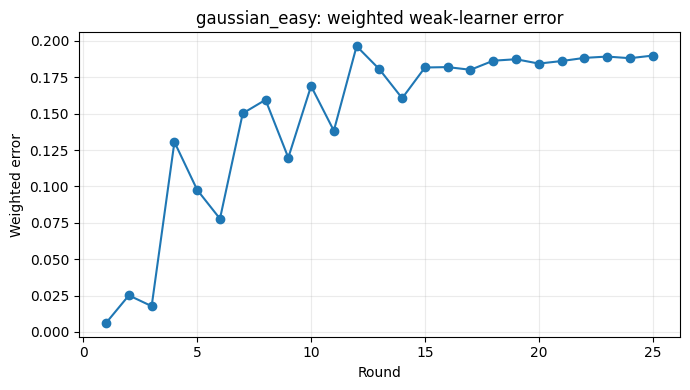

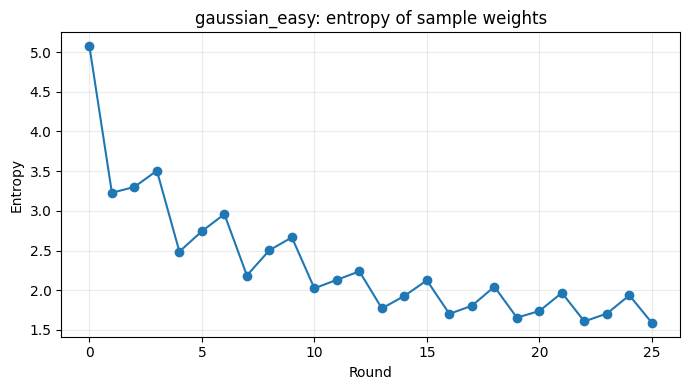

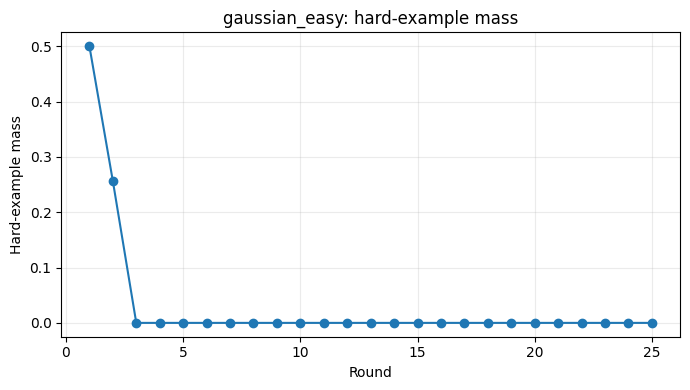

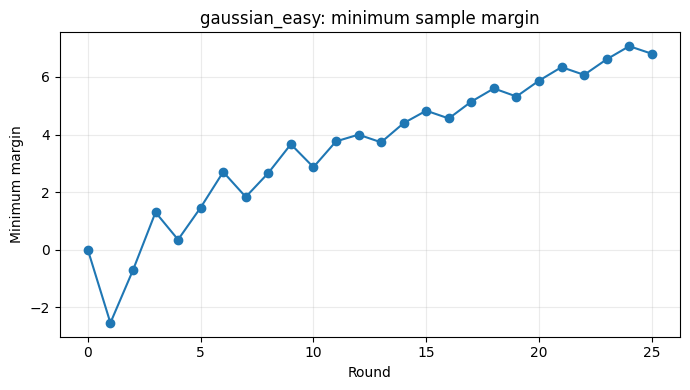

### gaussian_overlap

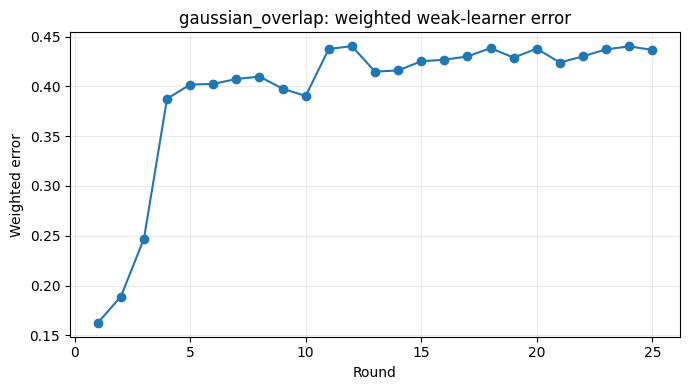

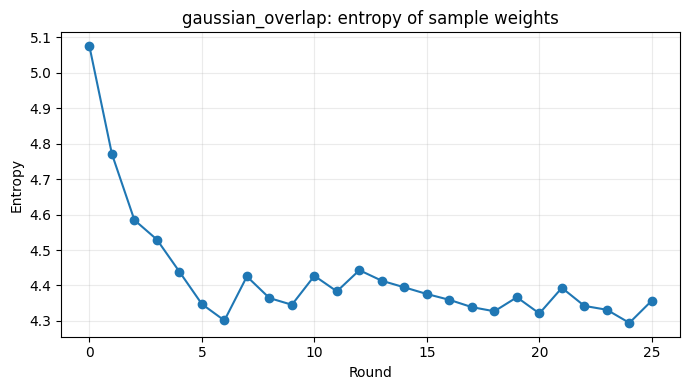

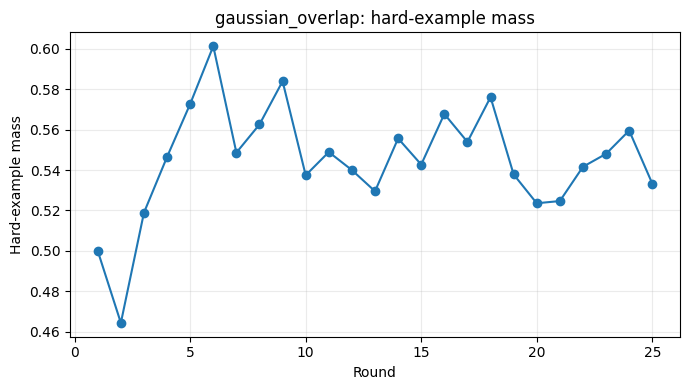

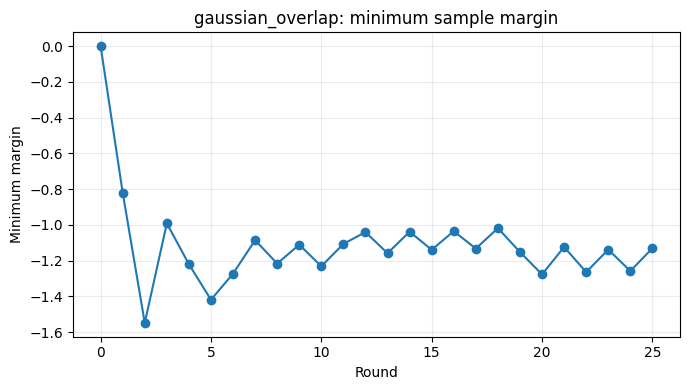

### xor_checkerboard

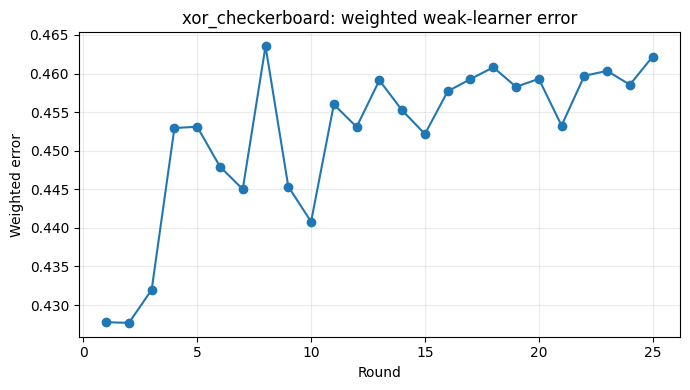

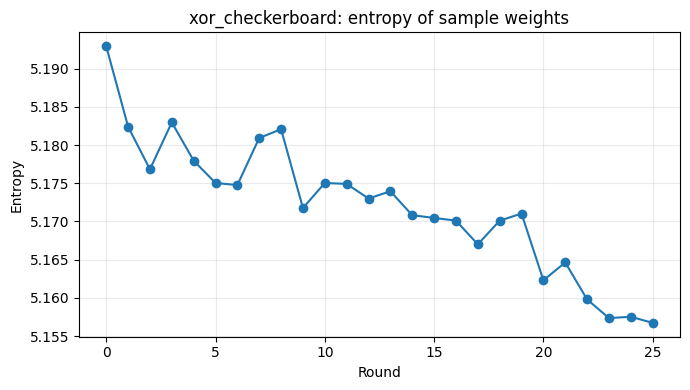

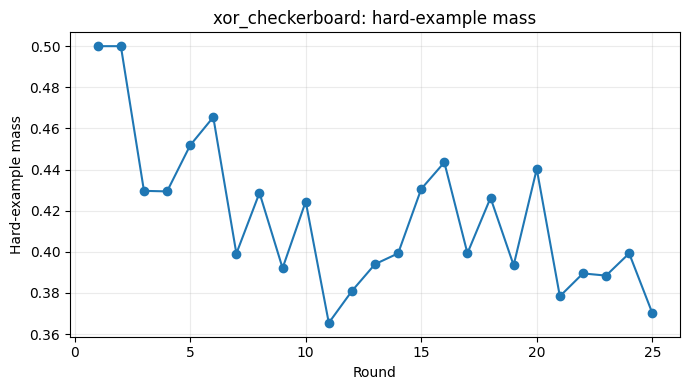

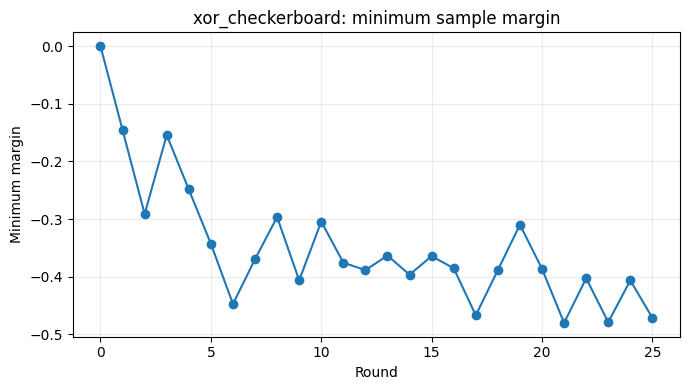

Figures saved under: results_adaboost\figures


In [10]:

def save_and_show_plot(path, title, x_values, y_values, y_label):
    plt.figure(figsize=(7, 4))
    plt.plot(x_values, y_values, marker="o")
    plt.xlabel("Round")
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

for name, payload in all_results.items():
    result = payload["result"]
    rounds_axis = np.arange(1, result["rounds"] + 1)
    state_axis = np.arange(0, result["rounds"] + 1)

    display(Markdown(f"### {name}"))

    save_and_show_plot(
        figures_dir / f"{name}_weighted_error.png",
        f"{name}: weighted weak-learner error",
        rounds_axis,
        result["weighted_errors"],
        "Weighted error",
    )

    save_and_show_plot(
        figures_dir / f"{name}_entropy.png",
        f"{name}: entropy of sample weights",
        state_axis,
        result["entropy_history"],
        "Entropy",
    )

    save_and_show_plot(
        figures_dir / f"{name}_hard_example_mass.png",
        f"{name}: hard-example mass",
        rounds_axis,
        result["hard_example_mass_history"],
        "Hard-example mass",
    )

    save_and_show_plot(
        figures_dir / f"{name}_minimum_margin.png",
        f"{name}: minimum sample margin",
        state_axis,
        np.min(result["margin_history"], axis=1),
        "Minimum margin",
    )

print("Figures saved under:", figures_dir)



## Interpretation checklist

Use the following checklist when reading the AdaBoost extension results.

- If the weighted weak-learner error stays below $1/2$, then the weak learner maintains positive edge.
- If the entropy decreases, then the sample weights are concentrating on fewer training examples.
- If the hard-example mass remains large, then substantial weight still sits on nonpositive-margin examples.
- If the minimum margin increases, then the ensemble is improving its worst-classified examples.
- If the training error decreases while entropy also decreases, then the algorithm is fitting the data while concentrating on difficult points.


In [11]:

display(Markdown("## Output locations"))
print("Report:", report_path)
print("Figures:", figures_dir)


## Output locations

Report: results_adaboost\adaboost_results.txt
Figures: results_adaboost\figures
